

# Option Delta - Definition, Intuition and Its Failures

   This repo explains what delta really means, how it connects to probability, how delta hedging works geometrically, and why delta inevitably fails in the real world.

---

## What is Delta - First Principles


1. **Mathmatical Definition**  

    For an option with price $V(S, t)$:
\begin{align*}
    \Delta = \frac{\partial V}{\partial S}
\end{align*}

    This answers: If the underlying moves by $1 right now, how much does the option price change?

2. **Black Scholes Definition**  

    For Black Scholes model, we have -
    
    option prices:
\begin{align*}
    C &= S \, N(d_1) - K e^{-rT} N(d_2) \\
    P &= K e^{-rT} N(-d_2) - S N(-d_1)  \\
\end{align*}

    put-call parity:
\begin{align*}
    C &- P = S - K e^{-rT}
\end{align*}

    option delta:
\begin{align*}
    \Delta C &= N(d_1) \\
    \Delta P &= N(-d_1) 
\end{align*}

3. **Economic interpretation**   
- The amount of underlying needed to hedge the option locally (delta hedging ratio)

- The slope of the option price as a function of spot

- The best first-order (linear) approximation to nonlinear option payoff at the current spot. 



---

## Delta vs. Implied Probability

1. **Black Scholes Perspective**  

    $N(x)$ denotes the standard normal cumulative distribution function, so that:
\begin{align*}
    N(d_1) + N(-d_1) = 1 \\
    N(d_2) + N(-d_2) = 1
\end{align*}

    $N(d_1)$ and $N(-d_1)$ are not constant since $d_1$ and $d_2$ depend on underlying price:
\begin{align*}
    d_1 &= \frac{\ln\!\left(\frac{S}{K}\right) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}, \quad \\
    d_2 &= d_1 - \sigma\sqrt{T}
\end{align*}


2. **Intuitive Diagram**  
 
    - $N(d_2)$ is the risk-neutral probability of finishing ITM. Divorced from associated payoff.
    - $N(d_1)$ is the option’s delta — riks-neutral replication of the option, i.e. probability-weighted exposure under stock numeraire. The value corresponds to the integral of payoffs between the strike price and infinity for a call (or zero for a put) assuming the underlying process is risk neutral.


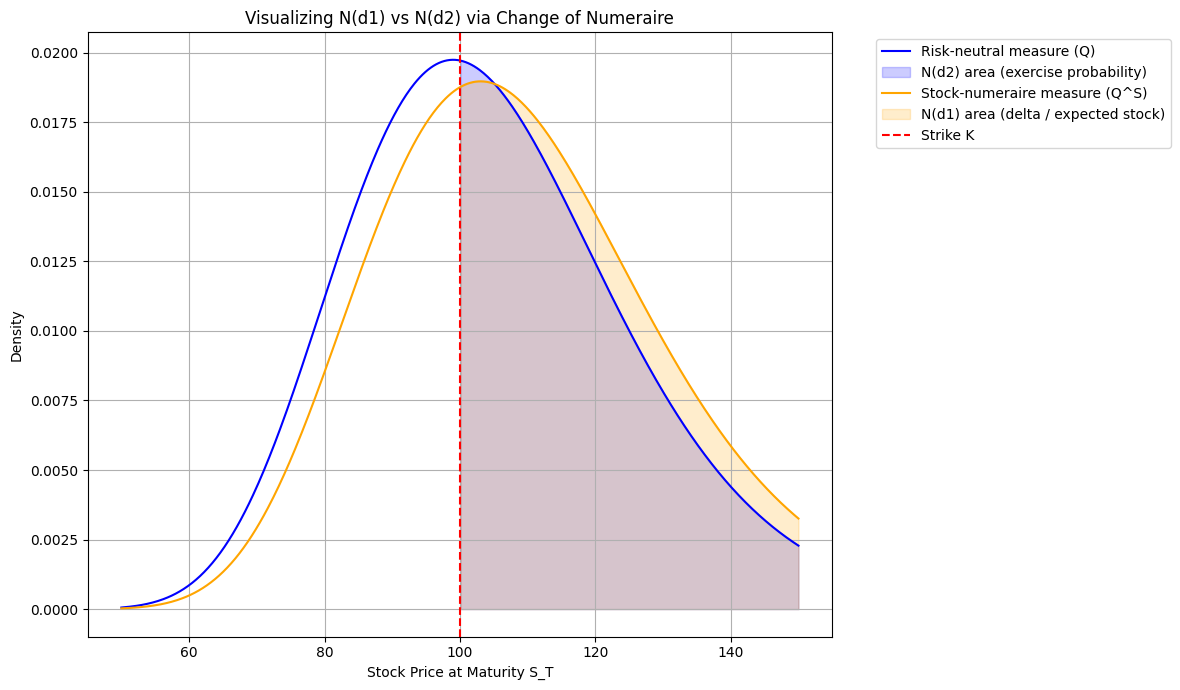

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Parameters for illustration
S0 = 100
K = 100
sigma = 0.2
T = 1
r = 0.05

# Compute d1 and d2
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)

# Stock price range for plotting
ST = np.linspace(50, 150, 500)

# PDFs under measures
# Risk-neutral measure (ln(ST) ~ N(ln(S0)+(r-0.5*sigma^2)T, sigma^2*T))
mu_rn = np.log(S0) + (r - 0.5*sigma**2)*T
pdf_rn = norm.pdf(np.log(ST), mu_rn, sigma*np.sqrt(T)) / ST

# Stock-numeraire measure (ln(ST) ~ N(ln(S0)+(r+0.5*sigma^2)T, sigma^2*T))
mu_stock = np.log(S0) + (r + 0.5*sigma**2)*T
pdf_stock = norm.pdf(np.log(ST), mu_stock, sigma*np.sqrt(T)) / ST

# Plot
plt.figure(figsize=(12,7))

# Risk-neutral curve
plt.plot(ST, pdf_rn, label='Risk-neutral measure (Q)', color='blue')
plt.fill_between(ST, 0, pdf_rn, where=(ST>K), color='blue', alpha=0.2, label='N(d2) area (exercise probability)')

# Stock-numeraire curve
plt.plot(ST, pdf_stock, label='Stock-numeraire measure (Q^S)', color='orange')
plt.fill_between(ST, 0, pdf_stock, where=(ST>K), color='orange', alpha=0.2, label='N(d1) area (delta / expected stock)')

# Strike
plt.axvline(K, color='red', linestyle='--', label='Strike K')

# Labels
plt.title("Visualizing N(d1) vs N(d2) via Change of Numeraire")
plt.xlabel("Stock Price at Maturity S_T")
plt.ylabel("Density")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



- Blue Curve: Risk-neutral Measure ($\mathbb{Q}$)
    - $N(d_2) =$ Shaded area beyond the strike. The risk-neutral probability the option finishes ITM -> multiplies the discounted strike $K e^{-rT}$ 

- Orange curve: Stock-numeraire measure ($\mathbb{Q^s}$)
    - $N(d_1) =$ Shaded area beyond the strike. The “delta-weighted probability” of receiving the stock -> equals delta, multiplies $S_0$.




---

## Delta Hedging

**Delta hedging is not just risk reduction — it actively generates P&L**  

- holder of long option position always profit from buy low sell high
- holder of short option position alywas loss from buy high sell low


following charts help understand the idea intuitively -

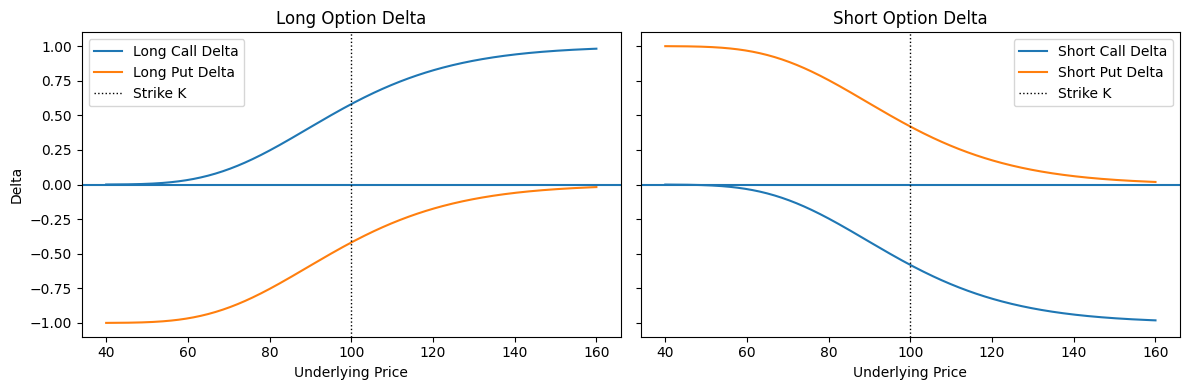

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Black-Scholes delta functions
def call_delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def put_delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1) - 1

# Parameters
K = 100
T = 1.0
r = 0.02
sigma = 0.25

# Underlying price range
S = np.linspace(40, 160, 400)

# Long option deltas
long_call = call_delta(S, K, T, r, sigma)
long_put = put_delta(S, K, T, r, sigma)

# Short option deltas (sign flip)
short_call = -long_call
short_put = -long_put

# ===== Plot: One Row, Two Charts =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Chart 1: Long Options
axes[0].plot(S, long_call, label="Long Call Delta")
axes[0].plot(S, long_put, label="Long Put Delta")
axes[0].axhline(0)
axes[0].axvline(K, color='k', linestyle=':', linewidth=1, label='Strike K')
axes[0].set_title("Long Option Delta")
axes[0].set_xlabel("Underlying Price")
axes[0].set_ylabel("Delta")
axes[0].legend()

# Chart 2: Short Options
axes[1].plot(S, short_call, label="Short Call Delta")
axes[1].plot(S, short_put, label="Short Put Delta")
axes[1].axhline(0)
axes[1].axvline(K, color='k', linestyle=':', linewidth=1, label='Strike K')
axes[1].set_title("Short Option Delta")
axes[1].set_xlabel("Underlying Price")
axes[1].legend()

plt.tight_layout()
plt.show()


- **Long Option**
    - $S \uparrow$   : position move to the right $\rightarrow$, delta $\uparrow$, portfolio underhedged, **short(-)** underlying asset to rebalance.
    - $S \downarrow$ : position move to the left $\leftarrow$, delta $\downarrow$, portfolio overderhedged, **long(+)** underlying asset to rebalance.
    - we pocketed a profit from adjusting local hedging ratio to the change of option delta, meaning we always buy low sell high.


- **Short Option**
    - $S \uparrow$   : position move to the right $\rightarrow$, delta $\downarrow$, portfolio overderhedged, **long(+)** underlying asset to rebalance.
    - $S \downarrow$ : position move to the left $\leftarrow$, delta $\uparrow$, portfolio underhedged, **short(-)** underlying asset to rebalance.
    - we lose money from adjusting local hedging ratio to the change of option delta, meaning we always buy high sell low.




**Trading Facts**

- Exact dynamic replication of an option is **impossible in practice**
    - the goal of delta hedging isn’t to build a perfect replication; it’s to **control the dominant linear risk** so the P&L is driven by higher-order effects.


- There is **no P&L at expiry** since delta hedging effectively:
    - increases the hedge ratio toward 1 as the option moves ITM
    - decreases the hedge ratio toward 0 as the option moves OTM
    - ensures option has zero payoff risk at expiry, meaning **all option P&L is realized through delta-hedging trades before expiry**.


- The option premium can be viewed as **the price paid for the right to profit from delta hedging**
    - this insight underpins Black–Scholes: option pricing equals the cost of a dynamically hedged, self-financing portfolio


- The P&L of delta hedging an option is the **diﬀerence between the implied volatility and the realized volatility**.
    - implied volatility (IV) determines the premium of the option
    - realized volatility (RV) determines the actual P&L from delta hedging the option until expiry.
    - **trading options and delta hedging them** means taking views on the spread between implied and realized volatility **(RV - IV)**.

- The **higher the volatility** (number and scale of moves in the underlying market) until expiry, the **higher the profit** from delta hedging a long option position.


---

## Why Delta Hedging Fail

Delta hedging only neutralizes first-order risk in an idealized, continuous, correctly specified world. In practice, several things break -

1. **Discrete hedging (rebalancing risk)** - Delta is a *local linear approximation*. Large moves reveal curvature.

    - Delta hedging is done at discrete times in reality.
    - Large price moves between hedges expose **gamma risk**: $\text{Hedging error} \approx \tfrac{1}{2}\Gamma (\Delta S)^2$
    - Fast markets, gaps, and overnight moves amplify this effect.



2. **Model misspecification (wrong delta)** - You think you are delta-neutral, but hidden directional risk remains.
    - Delta is **model-dependent** (often Black–Scholes).
    - If:
        - volatility is stochastic,
        - jumps exist,
        - skew matters,
    then model delta ≠ true delta.


3. **Stochastic volatility (vega–gamma interaction)** - Even perfect spot hedging does not isolate you from volatility risk.
    - Delta hedging assumes constant volatility.
    - In reality, volatility moves with spot (leverage effect).
    - A spot move causes:
        - delta change (gamma),
        - implied vol change (vega),
        - feedback into delta.


4. **Jumps and discontinuities** - Gamma hedges variance, not jumps.
    - Delta hedging assumes continuous price paths.
    - Earnings, macro news, and crises cause **jumps**.
    - Delta provides **no protection** against jump risk.


5. **Transaction costs and market impact** - You can hedge risk away, but you cannot hedge costs away.
    - Frequent re-hedging incurs:
        - bid–ask spreads,
        - slippage,
        - market impact.
    - These costs scale with:
        - volatility,
        - gamma,
        - hedge frequency.


6. **Correlation and multi-asset effects**
    - For index or basket options:
        - delta hedging ignores **correlation risk**.
    - Constituents may move differently than assumed.
    - Index delta ≠ sum of component deltas in stress.


7. **Financing, carry, and funding effects**
    - Delta hedging assumes frictionless financing.
    - In practice:
        - repo rates vary,
        - funding spreads change,
        - dividends are uncertain.
    - These effects bleed into long-run PnL.


8. **Path dependence of realized PnL**
    - Even if:
        - implied volatility equals realized volatility (ex post),
        - hedging is frequent,
    PnL still depends on the **price path**.


**Summary** 

- *Delta hedging is not guaranteed volatility arbitrage; it is a **path-dependent bet on realized variance vs implied variance**.*

- *Delta hedging fails because it only removes infinitesimal price risk under a specific model. Real markets have jumps, stochastic volatility, discrete hedging, costs, and feedback effects—so hedging error is inevitable.*


---

TODO: 1. whats your hedging strategy? Whats your rebalance freq? when there is event, how do you deal with? will you overhedge or underhedge? 2. relate to real market data? walk through whole pipeline from data to startegy to performance? beat benchmark / evaluation metrics 

## Practitioner Summary

- Delta is the **local hedge ratio** of an option, representing the slope of the option price with respect to spot. 

- While often linked to implied probability, delta is better understood as a **convexity-adjusted sensitivity** rather than a pure probability.

- Delta hedging **linearizes option exposure locally**, converting directional risk into gamma and theta risk. 

- In practice, delta **fails due to nonlinearity, discrete hedging, volatility mismatch, jumps, and model error** — making delta hedging an approximation, not a guarantee.